# CREATE SUPPLEMENTARY FIGURE 12D-F PANELS
## last updated: 08.01.25

In [45]:
import numpy as np
import pandas as pd
import csv
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator

### Jaccard index dataframe pre-processing

In [46]:
full_cohort_jaccs_df = pd.read_csv("full_tool_testing/ic_full_cohort_jacc_data.csv")

In [47]:
# load path to cycle-level data table with confidence assignment included
cycle_level_data_table = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_table)

In [48]:
cohort_df["Cycle Regions List"] = cohort_df["Cycle Regions List"].apply(ast.literal_eval)
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(ast.literal_eval)
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(lambda x: list(set(x)))

In [49]:
# load file with information about IC subtype of samples
subtype_info = 'full_tool_testing/BCarc_eniclust.csv'
subtype_df = pd.read_csv(subtype_info)
subtype_df = subtype_df[["Sample", "ENiClust", "ER"]]

In [50]:
cohort_ic_df = pd.merge(cohort_df, subtype_df, on="Sample", how="left")

In [51]:
# load path to cycle-level Jaccard index calculations
all_jaccs = 'full_tool_testing/ic_intrasample_filt_jacc_data.csv'
all_jaccs_df = pd.read_csv(all_jaccs)

In [52]:
all_ic_jaccs_df = all_jaccs_df.merge(subtype_df, left_on="Sample1", right_on="Sample", how="left").rename(columns={"ENiClust": "Sample1 eniclust"}).drop(columns=["Sample"])

all_ic_jaccs_df = all_ic_jaccs_df.merge(subtype_df, left_on="Sample2", right_on="Sample", how="left").rename(columns={"ENiClust": "Sample2 eniclust"}).drop(columns=["Sample"])

In [53]:
intersubtype_ic_jaccs_df = all_ic_jaccs_df[all_ic_jaccs_df["Sample1 eniclust"] != all_ic_jaccs_df["Sample2 eniclust"]]

In [54]:
intersubtype_ic_jaccs_df["Breakend Jaccard"] = intersubtype_ic_jaccs_df["Breakend Jaccard"].clip(upper=1,lower=0)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_2969/3947321067.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intersubtype_ic_jaccs_df["Breakend Jaccard"] = intersubtype_ic_jaccs_df["Breakend Jaccard"].clip(upper=1,lower=0)


In [55]:
intrasubtype_ic_jaccs_df = all_ic_jaccs_df[all_ic_jaccs_df["Sample1 eniclust"] == all_ic_jaccs_df["Sample2 eniclust"]]

In [56]:
intrasubtype_ic_jaccs_df["Breakend Jaccard"] = intrasubtype_ic_jaccs_df["Breakend Jaccard"].clip(upper=1,lower=0)

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_2969/790532324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intrasubtype_ic_jaccs_df["Breakend Jaccard"] = intrasubtype_ic_jaccs_df["Breakend Jaccard"].clip(upper=1,lower=0)


### Supp. Fig. 12D

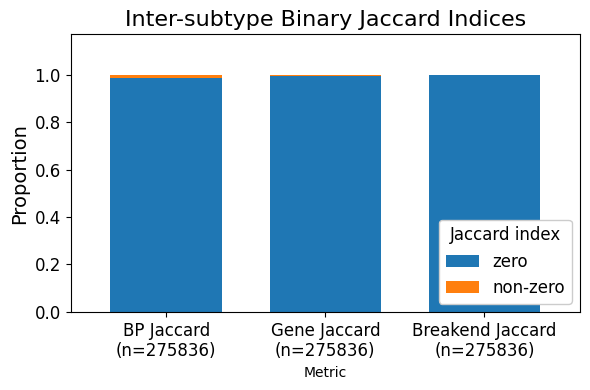

In [71]:
cols = ["BP Jaccard", "Gene Jaccard", "Breakend Jaccard"]
metric_order = ["BP Jaccard", "Gene Jaccard", "Breakend Jaccard"]
df_subset = intersubtype_ic_jaccs_df[cols].copy()

df_long = df_subset.melt(var_name="Metric", value_name="Jaccard")

# Create binary category: zero vs non-zero
df_long["Category"] = df_long["Jaccard"].apply(lambda x: "0" if x == 0 else ">0")

# Compute proportions
prop_df = (
    df_long.groupby(["Metric", "Category"])
    .size()
    .reset_index(name="count")
)

prop_df["proportion"] = prop_df.groupby("Metric")["count"].transform(lambda x: x / x.sum())

plot_df = (
    prop_df.pivot(index="Metric", columns="Category", values="proportion")
    .fillna(0)
    .reindex(metric_order)
)

plot_df = plot_df[["0", ">0"]]

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4),
    width=0.7
)

# Total n for each metric
total_n = df_long.groupby("Metric").size()

# Custom x-axis labels
xtick_labels = [
    f"{metric}\n(n={total_n[metric]})"
    for metric in metric_order
]

plt.ylabel("Proportion", fontsize=14)
plt.title("Inter-subtype Binary Jaccard Indices", fontsize=16)
ax.set_xticklabels(xtick_labels, rotation=0)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_ylim(0, 1.17)

plt.legend(title="Jaccard index", labels=["zero", "non-zero"], loc="lower right", frameon=True, framealpha=1.0, facecolor="white", fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

In [60]:
counts = (
    df_long.groupby(["Metric", "Category"])
    .size()
    .unstack(fill_value=0)
)

print(counts)

Category               0    >0
Metric                        
BP Jaccard        272445  3391
Breakend Jaccard  275068   768
Gene Jaccard      274240  1596


### Supp. Fig. 12E

In [36]:
cohort_ic_df["Cycle Gene Count"] = cohort_ic_df["Cycle Genes List"].apply(len)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Cycle Size (bp) vs. Cycle Gene Count: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.681e-270 U_stat=6.131e+05
Cycle Gene Count vs. Cycle Breakpoint Count: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.119e-167 U_stat=7.221e+04
Cycle Size (bp) vs. Cycle Breakpoint Count: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.230e-262 U_stat=6.131e+05


/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_2969/3961150938.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


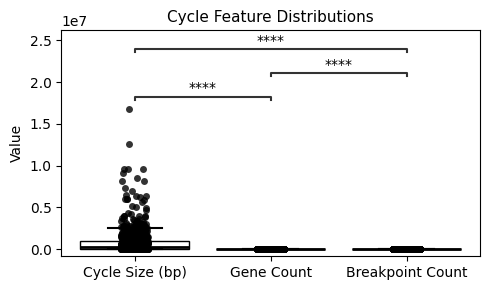

In [42]:
cols = ["Cycle Size (bp)", "Cycle Gene Count", "Cycle Breakpoint Count"]
df_subset = cohort_ic_df[cols].copy()

df_long = df_subset.melt(var_name="Metric", value_name="Value")

plt.figure(figsize=(5, 3))

ax = sns.boxplot(
    data=df_long,
    x="Metric",
    y="Value",
    whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    data=df_long,
    x="Metric",
    y="Value",
    color="black",
    alpha=0.8,
    jitter=True
)

pairs = [
    ("Cycle Size (bp)", "Cycle Gene Count"),
    ("Cycle Size (bp)", "Cycle Breakpoint Count"),
    ("Cycle Gene Count", "Cycle Breakpoint Count"),
]

annotator = Annotator(ax, pairs, data=df_long, x="Metric", y="Value")
annotator.configure(
    test="Mann-Whitney",
    comparisons_correction="bonferroni",
    text_format="star",
    loc="inside"
)
annotator.apply_and_annotate()

plt.xlabel("")
plt.ylabel("Value")
plt.title("Cycle Feature Distributions", fontsize=11)

ax.set_xticklabels([
    "Cycle Size (bp)",
    "Gene Count",
    "Breakpoint Count"
])

plt.tight_layout()
plt.show()

### Supp. Fig. 12F

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Gene Count vs. Breakpoint Count: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.040e-167 U_stat=7.221e+04


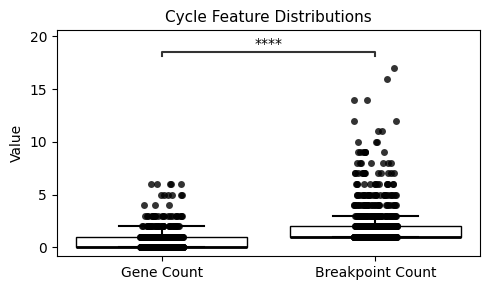

In [43]:
plot_df = cohort_ic_df[
    ["Cycle Genes List", "Cycle Breakpoint Count"]
].copy()

plot_df["Gene Count"] = plot_df["Cycle Genes List"].apply(
    lambda x: len(x) if isinstance(x, (list, tuple, set)) else 0
)

plot_df = plot_df.rename(columns={
    "Cycle Breakpoint Count": "Breakpoint Count"
})

df_long = plot_df.melt(
    value_vars=["Gene Count", "Breakpoint Count"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(5, 3))

ax = sns.boxplot(
    data=df_long,
    x="Metric",
    y="Value",
    whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    data=df_long,
    x="Metric",
    y="Value",
    color="black",
    alpha=0.8,
    jitter=True
)

pairs = [
    ("Gene Count", "Breakpoint Count")
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Value"
)

annotator.configure(
    test="Mann-Whitney",
    comparisons_correction="bonferroni",
    text_format="star",
    loc="inside"
)

annotator.apply_and_annotate()

plt.xlabel("")
plt.ylabel("Value")
plt.title("Cycle Feature Distributions", fontsize=11)

plt.tight_layout()
plt.show()

In [44]:
x = df_long.loc[
    df_long["Metric"] == "Gene Count",
    "Value"
].dropna()

y = df_long.loc[
    df_long["Metric"] == "Breakpoint Count",
    "Value"
].dropna()

# Mann-Whitney U test
U, p = mannwhitneyu(x, y, alternative="two-sided")

# Rank-biserial correlation
rbc = (2 * U) / (len(x) * len(y)) - 1

print("\nMann-Whitney U Test")
print("-" * 40)
print(f"Gene Count vs Breakpoint Count")
print(f"n1 = {len(x)}")
print(f"n2 = {len(y)}")
print(f"U statistic = {U:.1f}")
print(f"p value = {p:.6e}")
print(f"Rank-biserial correlation = {rbc:.4f}")


Mann-Whitney U Test
----------------------------------------
Gene Count vs Breakpoint Count
n1 = 783
n2 = 783
U statistic = 72211.0
p value = 1.039566e-167
Rank-biserial correlation = -0.7644
